# Task 2 – Working with the lead-conversion table

`mart_lead_conversions` has one row per lead, with the contract the lead led to. The queries below are plain SQL
on this one table. How leads are linked to contracts, and why 9 of 50 contracts are not in the table: see the
[README](../README.md#task-2--lead-to-conversion-model). The columns are documented in
`dbt/models/marts/_marts.yml`. Before running: `cd dbt && dbt build`.

**Three rules for working with the table:**
- **Counting rows counts leads.**
- **To count conversions or to sum premiums, filter on `is_last_touch`.** A conversion appears on each of its
  touchpoints, but it has exactly one last touch.
- **`unknown`** means that the value is missing or contradictory in the source. The charts leave it out; the
  tables keep it, so that they add up to all leads.

In [1]:
import plotly.express as px

# Shared by the notebooks, see notebooks/common/
from common import bar_chart, configure_plotly, query

configure_plotly()

## 1. The table

In [2]:
query("""
    select *
    from mart_lead_conversions
    order by lead_id
    limit 5
""")

,lead_id,lead_date,lead_month,vertical,source,region,email,is_converted,conversion_id,is_first_touch,is_last_touch,signed_date,contract_status,premium,days_to_sign
0,1001,2024-10-05,2024-10-01,haushalt,google,Oberoesterreich,hannah.mueller@gmail.com,False,<NA>,False,False,NaT,<NA>,<NA>,<NA>
1,1002,2024-02-12,2024-02-01,leben,google,Burgenland,leon.hofer@gmx.at,False,<NA>,False,False,NaT,<NA>,<NA>,<NA>
2,1003,2024-01-12,2024-01-01,auto,google,Vorarlberg,leon.hofer@gmx.at,True,5040,True,True,2024-01-16,active,570.49,4
3,1004,2024-07-28,2024-07-01,auto,newsletter,Kaernten,tobias.pichler@gmail.com,False,<NA>,False,False,NaT,<NA>,<NA>,<NA>
4,1005,2024-08-24,2024-08-01,leben,direct,Burgenland,paul.aigner@gmail.com,True,5014,True,True,2024-09-03,active,999.13,10


## 2. How many leads converted?

In [3]:
overview = query("""
    select
        count(*) as leads,
        count_if(is_converted) as converted_leads,
        count_if(not is_converted) as not_converted,
        count_if(is_last_touch) as contracts,
        count_if(is_last_touch and contract_status = 'active') as active_contracts,
        round(100.0 * count_if(is_last_touch) / count(*), 1) as conversion_rate_pct
    from mart_lead_conversions
""")
overview

,leads,converted_leads,not_converted,contracts,active_contracts,conversion_rate_pct
0,119,43,76,41,26,34.5


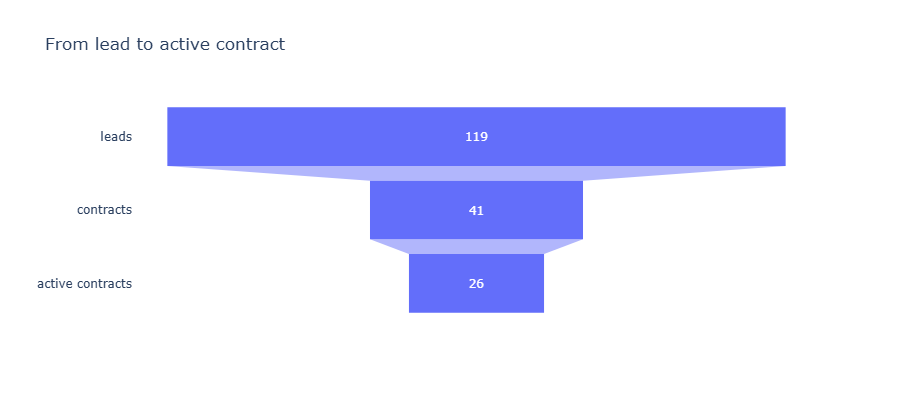

In [4]:
funnel = overview.melt(
    value_vars=["leads", "contracts", "active_contracts"],
    var_name="stage",
    value_name="count",
)
funnel["stage"] = funnel["stage"].str.replace("_", " ")
fig = px.funnel(
    funnel,
    x="count",
    y="stage",
    title="From lead to active contract",
    labels={"stage": "", "count": "number"},
)
fig.show()

**Reading:** 119 leads led to 41 contracts, 26 of which are active today.

## 3. How long does a conversion take?

Days to the signed contract, counted from the first and from the last touch, by the channel of that touch:

In [5]:
speed = query("""
    select
        source as channel,
        count_if(is_first_touch) as first_touches,
        round(avg(days_to_sign) filter (where is_first_touch), 1) as days_from_first_touch,
        count_if(is_last_touch) as last_touches,
        round(avg(days_to_sign) filter (where is_last_touch), 1) as days_from_last_touch
    from mart_lead_conversions
    where is_converted
    group by source
    order by channel
""")
speed

,channel,first_touches,days_from_first_touch,last_touches,days_from_last_touch
0,direct,11,24.3,12,23.3
1,google,13,20.6,11,20.2
2,newsletter,16,22.6,17,21.8
3,unknown,1,5.0,1,5.0


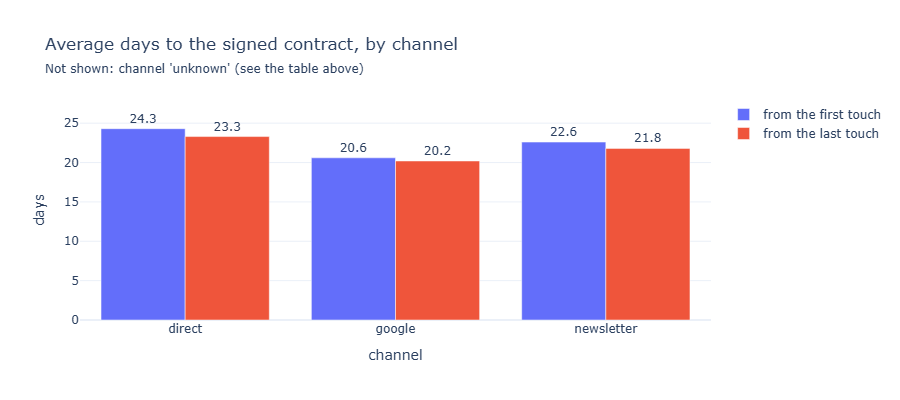

In [6]:
bar_chart(
    speed,
    x="channel",
    y=["days_from_first_touch", "days_from_last_touch"],
    title="Average days to the signed contract, by channel",
    labels={
        "days_from_first_touch": "from the first touch",
        "days_from_last_touch": "from the last touch",
    },
    y_title="days",
)

**Reading:** a contract is signed about three weeks after the last touch in every channel (20.2 days for google,
23.3 for direct).

## 4. Which conversions had several touchpoints?

In [7]:
query("""
    select conversion_id, lead_id, lead_date, source, is_first_touch, is_last_touch, premium
    from mart_lead_conversions
    where conversion_id in (
        select conversion_id
        from mart_lead_conversions
        group by conversion_id
        having count(*) > 1
    )
    order by conversion_id, lead_date, lead_id
""")

,conversion_id,lead_id,lead_date,source,is_first_touch,is_last_touch,premium
0,5004,1021,2024-03-10,google,True,False,260.71
1,5004,1020,2024-03-21,direct,False,True,260.71
2,5030,1111,2024-07-20,google,True,False,212.26
3,5030,1110,2024-08-02,newsletter,False,True,212.26


**Reading:** a conversion with two touchpoints appears on two rows, each with the contract's premium. Exactly one
of the rows is the last touch, which is why conversions are counted and premiums summed with `is_last_touch`.

## 5. Which leads have not converted?

The most recent leads without a contract, e.g. for a follow-up:

In [8]:
query("""
    select lead_id, lead_date, vertical, source, email
    from mart_lead_conversions
    where not is_converted
    order by lead_date desc, lead_id
    limit 10
""")

,lead_id,lead_date,vertical,source,email
0,1050,2024-10-30,auto,direct,laura.pichler@gmx.at
1,1095,2024-10-30,haushalt,google,emma.leitner@outlook.com
2,1062,2024-10-25,haushalt,newsletter,jakob.wagner@outlook.com
3,1093,2024-10-25,auto,direct,emma.leitner@outlook.com
4,1009,2024-10-22,leben,google,anna.aigner@gmx.at
5,1069,2024-10-22,haushalt,newsletter,mia.berger@gmail.com
6,1010,2024-10-20,haushalt,google,emma.aigner@outlook.com
7,1064,2024-10-20,haushalt,direct,eva.hofer@aon.at
8,1044,2024-10-17,haushalt,direct,paul.berger@gmail.com
9,1045,2024-10-11,unknown,direct,tobias.gruber@hotmail.com


**Reading:** all ten came in October, so some of them can still convert. A customer can appear more than once
(emma.leitner@outlook.com has two leads), so a mailing should go out per e-mail address, not per lead.